# OpenSourcePulse — Dimensionality Reduction

## Principal Component Analysis (PCA)

### Objective

PCA is applied to reduce the dimensionality of the repository feature
space while preserving as much variance as possible.

The analysis aims to identify the major underlying dimensions that explain
variation across GitHub repositories.

### Methodology

1. Select numerical analytical features.
2. Exclude identifiers and redundant/raw categorical variables.
3. Handle unavailable API-derived activity observations appropriately.
4. Apply log-transformed variables where appropriate.
5. Standardize features using StandardScaler.
6. Fit PCA.
7. Examine explained variance.
8. Analyze component loadings.
9. Visualize repositories in principal-component space.

PCA is used as an exploratory dimensionality-reduction technique and not as
a predictive model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv(
    "../data/processed/repository_features_clean.csv"
)

print("Dataset shape:", df.shape)
print()
print(df.head())

Dataset shape: (300, 48)

   repo_id         repo_name             owner  \
0   192904              pymc         pymc-devs   
1   374228         RestSharp         restsharp   
2   443962  FluentValidation  FluentValidation   
3   519832         mitmproxy         mitmproxy   
4   747698             sinon           sinonjs   

                           full_name  \
0                     pymc-devs/pymc   
1                restsharp/RestSharp   
2  FluentValidation/FluentValidation   
3                mitmproxy/mitmproxy   
4                      sinonjs/sinon   

                                         description  \
0  Bayesian Modeling and Probabilistic Programmin...   
1           Simple REST and HTTP API Client for .NET   
2  A popular .NET validation library for building...   
3  An interactive TLS-capable intercepting HTTP p...   
4        Test spies, stubs and mocks for JavaScript.   

                                            html_url    language  \
0                  https://

In [3]:
print("Available numerical features:")
print()

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

for column in numeric_columns:
    print(column)

Available numerical features:

repo_id
stars
forks
watchers
open_issues
size_kb
repository_age_days
repository_age_years
days_since_update
days_since_push
contributors_count
total_contributions
top_contributor_contributions
top_contributor_share
commits_365d
active_months
peak_monthly_commits
mean_monthly_commits
monthly_commit_std
activity_consistency
collected_commits
fork_star_ratio
issues_per_star
commits_per_active_month
log1p_stars
log1p_forks
log1p_open_issues
log1p_size_kb
log1p_commits_365d
log1p_contributors_count
log1p_total_contributions
log1p_peak_monthly_commits


In [4]:
# PCA feature selection
#
# Excluded:
# - repo_id: identifier, not an analytical feature
# - watchers: redundant with stars in this dataset
# - collected_commits: collection metadata/redundant with commits_365d
# - raw variables with log1p counterparts: raw skewed versions
# - repository_age_days: redundant with repository_age_years
# - derived ratios: retained for later analysis, not PCA
# - commits_per_active_month: undefined for zero-activity repositories
# - activity_consistency: derived from active_months
#
# Selected features represent distinct repository dimensions.

pca_features = [
    "log1p_stars",
    "log1p_forks",
    "log1p_open_issues",
    "log1p_size_kb",
    "repository_age_years",
    "days_since_update",
    "days_since_push",
    "log1p_contributors_count",
    "log1p_total_contributions",
    "top_contributor_share",
    "log1p_commits_365d",
    "active_months",
    "log1p_peak_monthly_commits",
    "mean_monthly_commits",
    "monthly_commit_std"
]

print("PCA feature set:")
print("----------------")
for i, feature in enumerate(pca_features, start=1):
    print(f"{i:2}. {feature}")

print()
print("Number of PCA features:", len(pca_features))

PCA feature set:
----------------
 1. log1p_stars
 2. log1p_forks
 3. log1p_open_issues
 4. log1p_size_kb
 5. repository_age_years
 6. days_since_update
 7. days_since_push
 8. log1p_contributors_count
 9. log1p_total_contributions
10. top_contributor_share
11. log1p_commits_365d
12. active_months
13. log1p_peak_monthly_commits
14. mean_monthly_commits
15. monthly_commit_std

Number of PCA features: 15


In [5]:
pca_missing = df[pca_features].isna().sum()

print("Missing values in PCA features:")
print(pca_missing[pca_missing > 0])

print()
print(
    "Rows with any missing PCA value:",
    df[pca_features].isna().any(axis=1).sum()
)

Missing values in PCA features:
log1p_contributors_count      1
log1p_total_contributions     1
top_contributor_share         1
log1p_commits_365d            2
active_months                 2
log1p_peak_monthly_commits    2
mean_monthly_commits          2
monthly_commit_std            2
dtype: int64

Rows with any missing PCA value: 2


In [6]:
pca_df = df[pca_features].copy()

pca_complete = pca_df.dropna()

print("Original repositories:", len(df))
print("Complete PCA observations:", len(pca_complete))
print("Excluded from PCA:", len(df) - len(pca_complete))

Original repositories: 300
Complete PCA observations: 298
Excluded from PCA: 2


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(pca_complete)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=pca_features,
    index=pca_complete.index
)

print("Scaled PCA matrix shape:", X_scaled_df.shape)
print()
print("Mean of first five standardized features:")
print(X_scaled_df.iloc[:, :5].mean())

print()
print("Standard deviation of first five standardized features:")
print(X_scaled_df.iloc[:, :5].std())

Scaled PCA matrix shape: (298, 15)

Mean of first five standardized features:
log1p_stars            -4.649525e-16
log1p_forks             3.338120e-16
log1p_open_issues      -8.941393e-17
log1p_size_kb           8.345301e-17
repository_age_years    9.537486e-17
dtype: float64

Standard deviation of first five standardized features:
log1p_stars             1.001682
log1p_forks             1.001682
log1p_open_issues       1.001682
log1p_size_kb           1.001682
repository_age_years    1.001682
dtype: float64


In [8]:
# Fit PCA with all available components

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("PCA completed successfully")
print("Original feature dimensions:", X_scaled.shape[1])
print("PCA dimensions:", X_pca.shape[1])

PCA completed successfully
Original feature dimensions: 15
PCA dimensions: 15


In [9]:
explained_variance = pca.explained_variance_ratio_

explained_variance_df = pd.DataFrame({
    "Principal Component": [
        f"PC{i+1}" for i in range(len(explained_variance))
    ],
    "Explained Variance Ratio": explained_variance,
    "Explained Variance (%)": explained_variance * 100,
    "Cumulative Variance (%)": np.cumsum(explained_variance) * 100
})

explained_variance_df

,Principal Component,Explained Variance Ratio,Explained Variance (%),Cumulative Variance (%)
0,PC1,0.467353,46.735331,46.735331
1,PC2,0.130318,13.031757,59.767088
2,PC3,0.099005,9.900511,69.667599
3,PC4,0.079815,7.981519,77.649118
4,PC5,0.051926,5.192598,82.841716
5,PC6,0.042651,4.265093,87.106809
6,PC7,0.035504,3.550436,90.657245
7,PC8,0.031525,3.152487,93.809733
8,PC9,0.025104,2.510367,96.320100
9,PC10,0.018410,1.840968,98.161068


In [10]:
print("PCA Explained Variance")
print("=====================")

for i, variance in enumerate(explained_variance, start=1):
    cumulative = np.sum(explained_variance[:i])

    print(
        f"PC{i:02d}: "
        f"{variance * 100:.2f}% "
        f"| Cumulative: {cumulative * 100:.2f}%"
    )

PCA Explained Variance
PC01: 46.74% | Cumulative: 46.74%
PC02: 13.03% | Cumulative: 59.77%
PC03: 9.90% | Cumulative: 69.67%
PC04: 7.98% | Cumulative: 77.65%
PC05: 5.19% | Cumulative: 82.84%
PC06: 4.27% | Cumulative: 87.11%
PC07: 3.55% | Cumulative: 90.66%
PC08: 3.15% | Cumulative: 93.81%
PC09: 2.51% | Cumulative: 96.32%
PC10: 1.84% | Cumulative: 98.16%
PC11: 0.76% | Cumulative: 98.92%
PC12: 0.60% | Cumulative: 99.53%
PC13: 0.35% | Cumulative: 99.88%
PC14: 0.10% | Cumulative: 99.97%
PC15: 0.03% | Cumulative: 100.00%


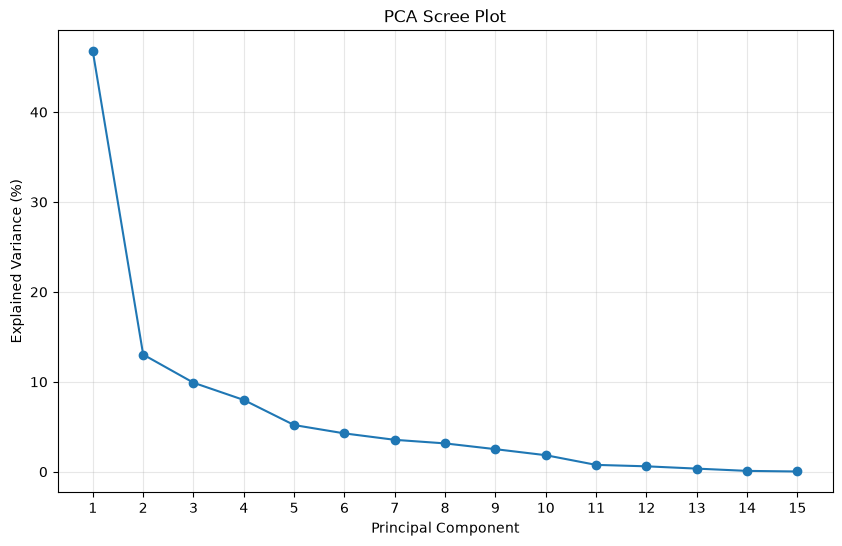

In [11]:
plt.figure(figsize=(10, 6))

components = np.arange(1, len(explained_variance) + 1)

plt.plot(
    components,
    explained_variance * 100,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("PCA Scree Plot")
plt.xticks(components)
plt.grid(True, alpha=0.3)

plt.show()

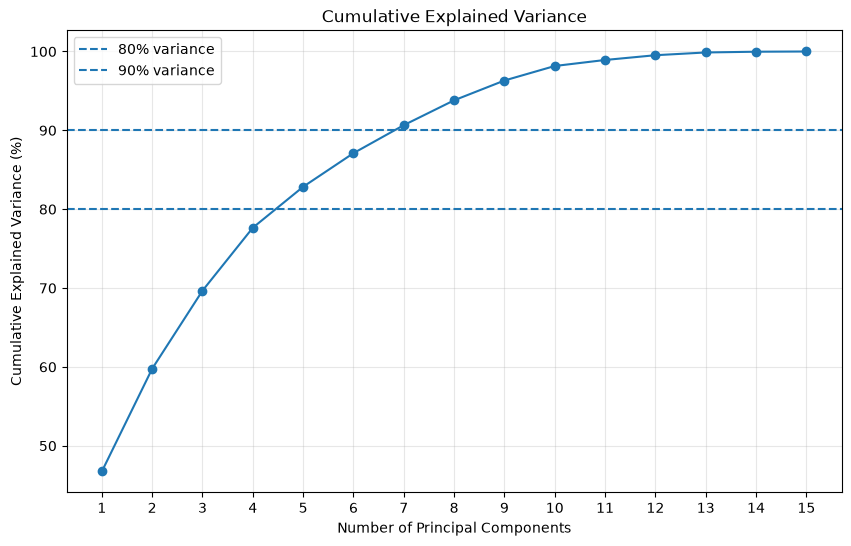

In [12]:
cumulative_variance = np.cumsum(
    explained_variance
) * 100

plt.figure(figsize=(10, 6))

plt.plot(
    components,
    cumulative_variance,
    marker="o"
)

plt.axhline(
    80,
    linestyle="--",
    label="80% variance"
)

plt.axhline(
    90,
    linestyle="--",
    label="90% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")
plt.xticks(components)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [13]:
# PCA component loadings

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=[
        f"PC{i+1}"
        for i in range(pca.n_components_)
    ]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
log1p_stars,0.290224,-0.070234,0.153373,0.475487,-0.009293,-0.076876,0.254875,0.191376,0.163503,0.055223,-0.023689,-0.084324,0.716374,-0.054187,0.007804
log1p_forks,0.284281,-0.052059,0.197584,0.458367,-0.066621,-0.079103,0.229995,0.288964,0.197306,-0.124506,-0.033868,-0.067872,-0.677799,0.025275,-0.002183
log1p_open_issues,0.233691,-0.094844,0.295528,0.146009,-0.444728,0.379416,-0.142661,-0.559379,-0.092233,-0.349836,0.137606,0.045416,0.028538,-0.005201,-0.003164
log1p_size_kb,0.267970,0.047212,0.012778,-0.236697,-0.198930,0.342091,-0.345668,0.703143,-0.146598,-0.194441,0.047133,0.169718,0.086817,-0.036963,0.007173
repository_age_years,-0.063210,-0.186393,0.571033,-0.249106,0.605676,0.072290,0.125008,0.016112,0.009484,-0.411173,-0.093233,0.040296,0.043754,-0.060120,0.013290
days_since_update,-0.233592,0.106726,0.150581,-0.398342,-0.431582,0.015914,0.301824,0.076803,0.678151,-0.078166,0.000941,-0.003216,0.055856,-0.006946,-0.001728
days_since_push,-0.247475,0.079663,0.330177,-0.064388,-0.331057,-0.077716,0.499223,0.142401,-0.638392,0.146517,-0.002294,0.070708,-0.004906,0.007797,-0.002074
log1p_contributors_count,0.303160,-0.254285,0.219680,-0.143109,0.040705,-0.085704,-0.017531,-0.096641,0.126188,0.516832,0.139377,0.667515,-0.056638,0.069250,0.000762
log1p_total_contributions,0.299692,-0.178049,0.130991,-0.273325,0.031027,0.371353,0.066994,-0.035603,-0.014388,0.480904,-0.194997,-0.603191,-0.066418,0.052430,-0.038689
top_contributor_share,-0.223048,0.109388,-0.250354,0.223000,0.228430,0.744693,0.359347,0.012797,0.072939,0.086254,0.051660,0.268256,-0.028652,0.039605,-0.007517


In [14]:
for pc in loadings.columns[:7]:

    print()
    print("=" * 60)
    print(pc)
    print("=" * 60)

    component_loadings = (
        loadings[pc]
        .sort_values(
            key=lambda x: x.abs(),
            ascending=False
        )
    )

    print(
        component_loadings.head(8)
    )


PC1
log1p_commits_365d            0.336524
log1p_peak_monthly_commits    0.331553
active_months                 0.311738
log1p_contributors_count      0.303160
log1p_total_contributions     0.299692
log1p_stars                   0.290224
log1p_forks                   0.284281
log1p_size_kb                 0.267970
Name: PC1, dtype: float64

PC2
mean_monthly_commits          0.631150
monthly_commit_std            0.631051
log1p_contributors_count     -0.254285
repository_age_years         -0.186393
log1p_total_contributions    -0.178049
log1p_peak_monthly_commits    0.120080
top_contributor_share         0.109388
days_since_update             0.106726
Name: PC2, dtype: float64

PC3
repository_age_years          0.571033
days_since_push               0.330177
log1p_open_issues             0.295528
active_months                -0.250991
top_contributor_share        -0.250354
log1p_peak_monthly_commits   -0.240219
log1p_commits_365d           -0.238909
log1p_contributors_count      0.2196

In [15]:
absolute_loadings = loadings.iloc[:, :7].abs()

absolute_loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
log1p_stars,0.290224,0.070234,0.153373,0.475487,0.009293,0.076876,0.254875
log1p_forks,0.284281,0.052059,0.197584,0.458367,0.066621,0.079103,0.229995
log1p_open_issues,0.233691,0.094844,0.295528,0.146009,0.444728,0.379416,0.142661
log1p_size_kb,0.267970,0.047212,0.012778,0.236697,0.198930,0.342091,0.345668
repository_age_years,0.063210,0.186393,0.571033,0.249106,0.605676,0.072290,0.125008
days_since_update,0.233592,0.106726,0.150581,0.398342,0.431582,0.015914,0.301824
days_since_push,0.247475,0.079663,0.330177,0.064388,0.331057,0.077716,0.499223
log1p_contributors_count,0.303160,0.254285,0.219680,0.143109,0.040705,0.085704,0.017531
log1p_total_contributions,0.299692,0.178049,0.130991,0.273325,0.031027,0.371353,0.066994
top_contributor_share,0.223048,0.109388,0.250354,0.223000,0.228430,0.744693,0.359347


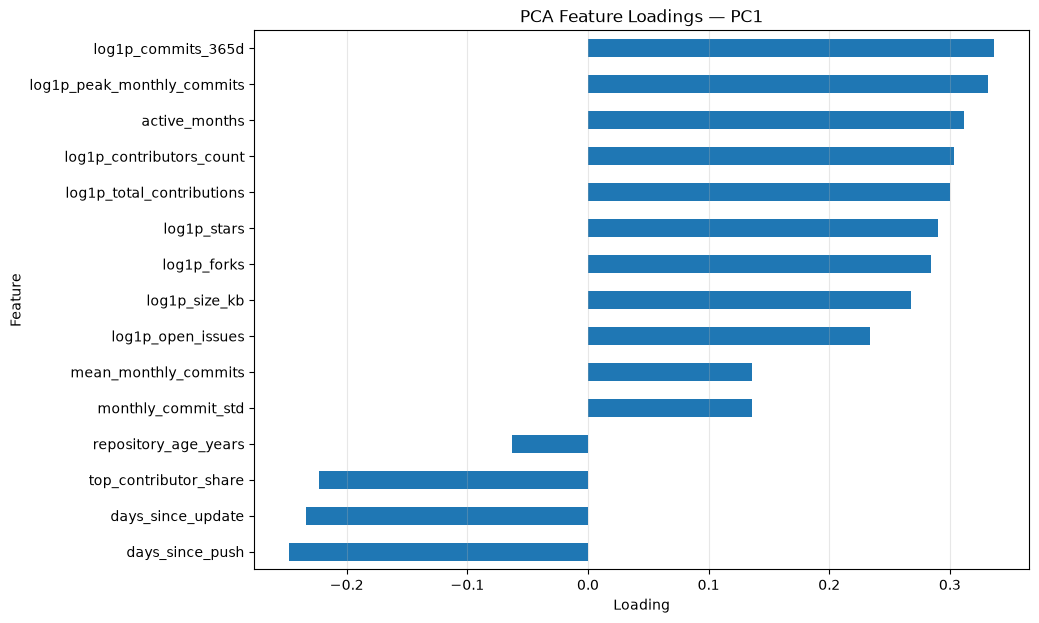

In [16]:
pc1_loadings = (
    loadings["PC1"]
    .sort_values()
)

plt.figure(figsize=(10, 7))

pc1_loadings.plot(
    kind="barh"
)

plt.xlabel("Loading")
plt.ylabel("Feature")
plt.title("PCA Feature Loadings — PC1")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

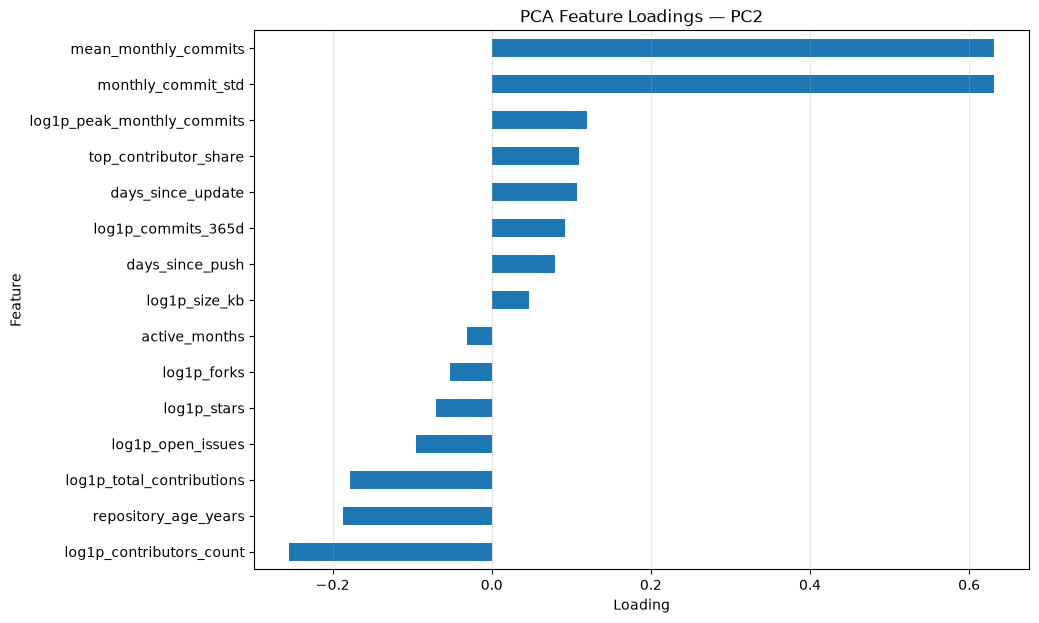

In [17]:
pc2_loadings = (
    loadings["PC2"]
    .sort_values()
)

plt.figure(figsize=(10, 7))

pc2_loadings.plot(
    kind="barh"
)

plt.xlabel("Loading")
plt.ylabel("Feature")
plt.title("PCA Feature Loadings — PC2")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

In [18]:
# Create repository-level PCA scores

pca_scores = pd.DataFrame(
    X_pca,
    columns=[
        f"PC{i+1}"
        for i in range(X_pca.shape[1])
    ],
    index=pca_complete.index
)

# Add repository information
pca_scores["repo_id"] = df.loc[
    pca_complete.index,
    "repo_id"
]

pca_scores["full_name"] = df.loc[
    pca_complete.index,
    "full_name"
].values

pca_scores["language"] = df.loc[
    pca_complete.index,
    "language_normalized"
].values

print("PCA score dataset shape:", pca_scores.shape)
print()
print(pca_scores.head())

PCA score dataset shape: (298, 18)

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  2.761473 -1.281890  1.449280 -1.711310  0.622527 -0.070084 -0.453892   
1  1.135587 -1.026894  1.150807 -0.830114  1.349389 -0.356299 -0.277482   
2  0.290496 -0.860458  0.368483 -0.715888  2.368164  0.428510  0.534353   
3  2.636867 -1.364760  1.472388 -0.732781  0.826335  0.267837  0.270927   
4  1.249690 -1.090771  1.210673 -1.367298  0.970748 -0.378552 -0.402374   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  0.154119 -0.317853 -1.004206  0.366913 -0.061417 -0.083990 -0.136536   
1  0.339560  0.129820 -0.284678 -0.208634  0.285496 -0.180136 -0.059159   
2  0.776701  0.349617  0.433811  0.440516  0.408452 -0.105687  0.029142   
3 -0.119673  0.097863 -0.473880  0.315779 -0.102766  0.113246 -0.049282   
4  0.054548  0.217899 -0.148752 -0.023699  0.129918  0.178002 -0.032146   

       PC15  repo_id                          full_name    lan

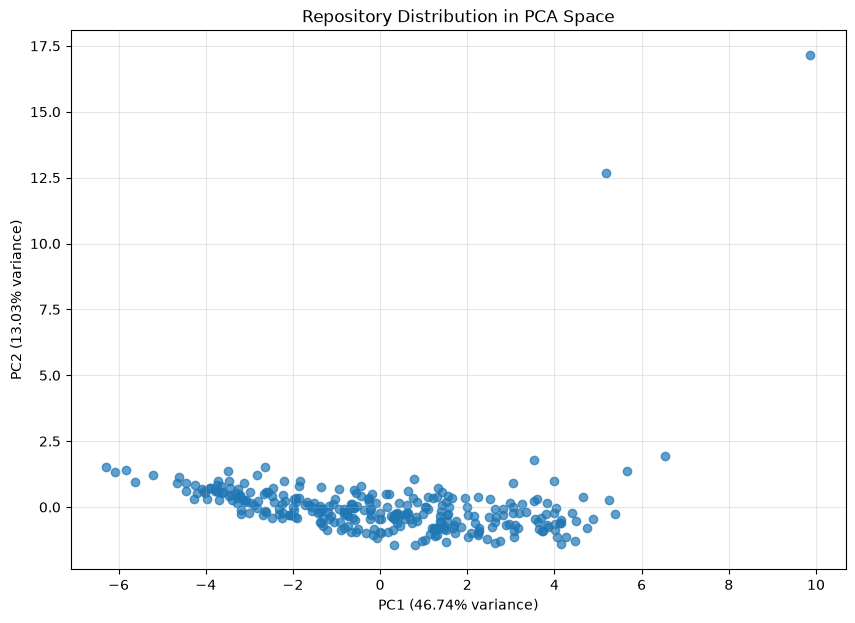

In [19]:
plt.figure(figsize=(10, 7))

plt.scatter(
    pca_scores["PC1"],
    pca_scores["PC2"],
    alpha=0.7
)

plt.xlabel(
    f"PC1 (46.74% variance)"
)

plt.ylabel(
    f"PC2 (13.03% variance)"
)

plt.title(
    "Repository Distribution in PCA Space"
)

plt.grid(
    alpha=0.3
)

plt.show()

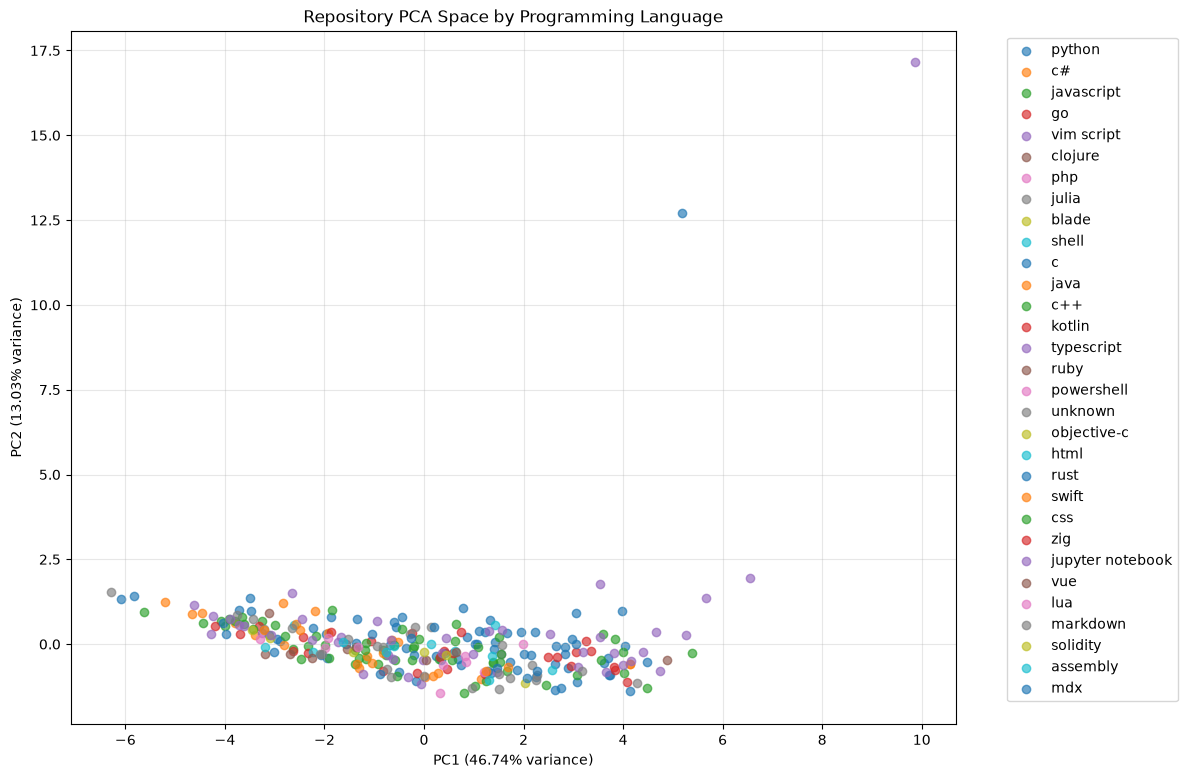

In [20]:
plt.figure(figsize=(12, 8))

languages = pca_scores["language"].dropna().unique()

for language in languages:

    subset = pca_scores[
        pca_scores["language"] == language
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.65,
        label=language
    )

plt.xlabel(
    "PC1 (46.74% variance)"
)

plt.ylabel(
    "PC2 (13.03% variance)"
)

plt.title(
    "Repository PCA Space by Programming Language"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [21]:
n_components = 7

variance_retained = (
    pca.explained_variance_ratio_[
        :n_components
    ].sum()
)

original_dimensions = len(pca_features)
reduced_dimensions = n_components

reduction_percentage = (
    1 -
    reduced_dimensions / original_dimensions
) * 100

print("PCA Dimensionality Reduction")
print("============================")
print("Original dimensions :", original_dimensions)
print("Reduced dimensions  :", reduced_dimensions)
print(
    "Variance retained   :",
    f"{variance_retained * 100:.2f}%"
)
print(
    "Dimensionality reduction:",
    f"{reduction_percentage:.2f}%"
)

PCA Dimensionality Reduction
Original dimensions : 15
Reduced dimensions  : 7
Variance retained   : 90.66%
Dimensionality reduction: 53.33%


In [22]:
# Save PCA explained variance

explained_variance_df.to_csv(
    "../reports/pca_explained_variance.csv",
    index=False
)

# Save PCA loadings

loadings.to_csv(
    "../reports/pca_loadings.csv"
)

# Save repository PCA scores

pca_scores.to_csv(
    "../reports/pca_repository_scores.csv",
    index=False
)

print("PCA analysis files saved successfully.")

PCA analysis files saved successfully.


In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Clustering libraries imported successfully")

Clustering libraries imported successfully


In [24]:
k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(
        kmeans.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )

cluster_evaluation = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

cluster_evaluation

,k,inertia,silhouette_score
0,2,3041.102196,0.292439
1,3,2482.235333,0.298417
2,4,2108.765100,0.211101
3,5,1890.591425,0.196796
4,6,1706.910757,0.193374
5,7,1570.598028,0.188944
6,8,1482.116539,0.182351


In [25]:
print("K-Means Cluster Evaluation")
print("==========================")

for _, row in cluster_evaluation.iterrows():

    print(
        f"k={int(row['k'])}: "
        f"Inertia={row['inertia']:.2f}, "
        f"Silhouette={row['silhouette_score']:.4f}"
    )

K-Means Cluster Evaluation
k=2: Inertia=3041.10, Silhouette=0.2924
k=3: Inertia=2482.24, Silhouette=0.2984
k=4: Inertia=2108.77, Silhouette=0.2111
k=5: Inertia=1890.59, Silhouette=0.1968
k=6: Inertia=1706.91, Silhouette=0.1934
k=7: Inertia=1570.60, Silhouette=0.1889
k=8: Inertia=1482.12, Silhouette=0.1824


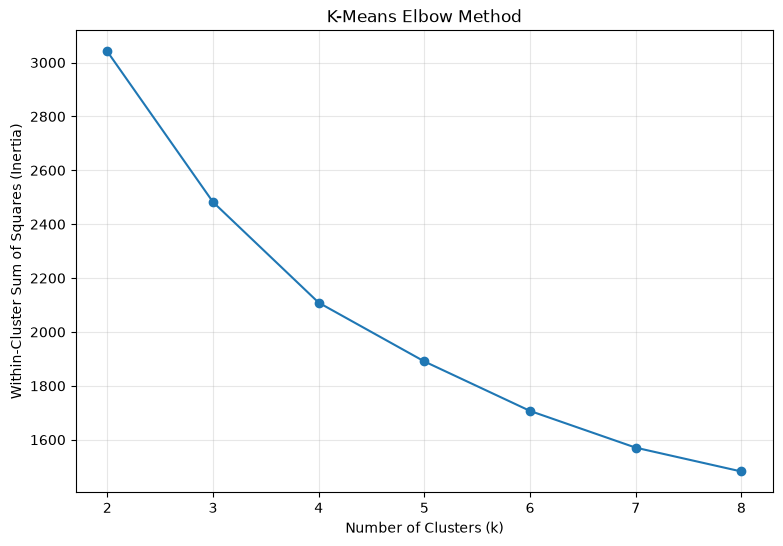

In [26]:
plt.figure(figsize=(9, 6))

plt.plot(
    cluster_evaluation["k"],
    cluster_evaluation["inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("K-Means Elbow Method")

plt.xticks(
    list(k_values)
)

plt.grid(
    alpha=0.3
)

plt.show()

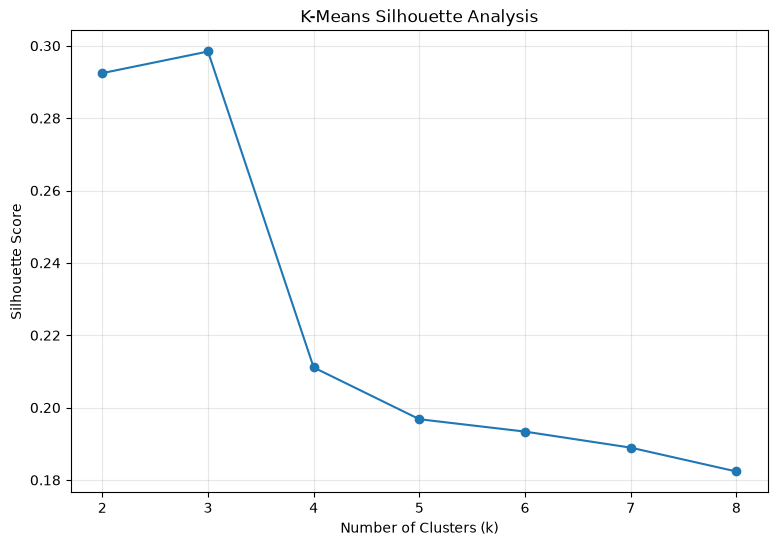

In [28]:
plt.figure(figsize=(9, 6))

plt.plot(
    cluster_evaluation["k"],
    cluster_evaluation["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Analysis")

plt.xticks(
    list(k_values)
)

plt.grid(
    alpha=0.3
)

plt.show()

In [29]:
# Final K-Means model

optimal_k = 3

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

pca_scores["cluster"] = cluster_labels

print("Final K-Means model fitted")
print("Number of clusters:", optimal_k)
print()
print("Cluster sizes:")
print(
    pca_scores["cluster"]
    .value_counts()
    .sort_index()
)

Final K-Means model fitted
Number of clusters: 3

Cluster sizes:
cluster
0    141
1    155
2      2
Name: count, dtype: int64


In [30]:
# Add cluster labels back to the analytical dataset

cluster_df = df.loc[
    pca_complete.index
].copy()

cluster_df["cluster"] = cluster_labels

print("Clustered dataset shape:", cluster_df.shape)

Clustered dataset shape: (298, 49)


In [31]:
cluster_profile = (
    cluster_df
    .groupby("cluster")
    .agg(
        repositories=("repo_id", "count"),
        median_stars=("stars", "median"),
        median_forks=("forks", "median"),
        median_commits_365d=("commits_365d", "median"),
        median_contributors=("contributors_count", "median"),
        median_active_months=("active_months", "median"),
        median_days_since_push=("days_since_push", "median"),
        median_days_since_update=("days_since_update", "median"),
        median_repository_age=("repository_age_years", "median"),
        median_top_contributor_share=(
            "top_contributor_share",
            "median"
        )
    )
    .reset_index()
)

cluster_profile

,cluster,repositories,median_stars,median_forks,median_commits_365d,median_contributors,median_active_months,median_days_since_push,median_days_since_update,median_repository_age,median_top_contributor_share
0,0,141,43655.0,4261.0,316.0,209.0,12.0,3.0,0.0,8.104038,0.415698
1,1,155,2489.0,330.0,0.0,15.0,0.0,420.0,2.0,9.976728,0.765625
2,2,2,319654.5,73432.0,93189.0,188.5,12.0,0.0,0.0,7.926078,0.281510


In [32]:
cluster_means = (
    cluster_df
    .groupby("cluster")
    .agg(
        repositories=("repo_id", "count"),
        mean_stars=("stars", "mean"),
        mean_forks=("forks", "mean"),
        mean_commits_365d=("commits_365d", "mean"),
        mean_contributors=("contributors_count", "mean"),
        mean_active_months=("active_months", "mean"),
        mean_days_since_push=("days_since_push", "mean"),
        mean_days_since_update=("days_since_update", "mean"),
        mean_repository_age=("repository_age_years", "mean"),
        mean_top_contributor_share=(
            "top_contributor_share",
            "mean"
        )
    )
    .reset_index()
)

cluster_means

,cluster,repositories,mean_stars,mean_forks,mean_commits_365d,mean_contributors,mean_active_months,mean_days_since_push,mean_days_since_update,mean_repository_age,mean_top_contributor_share
0,0,141,76799.524823,10877.41844,1366.411348,231.695035,10.333333,23.453901,0.64539,7.836680,0.472215
1,1,155,9003.219355,1193.83871,14.561290,27.167742,1.670968,730.309677,5.76129,9.287638,0.725370
2,2,2,319654.500000,73432.00000,93189.000000,188.500000,12.000000,0.000000,0.00000,7.926078,0.281510


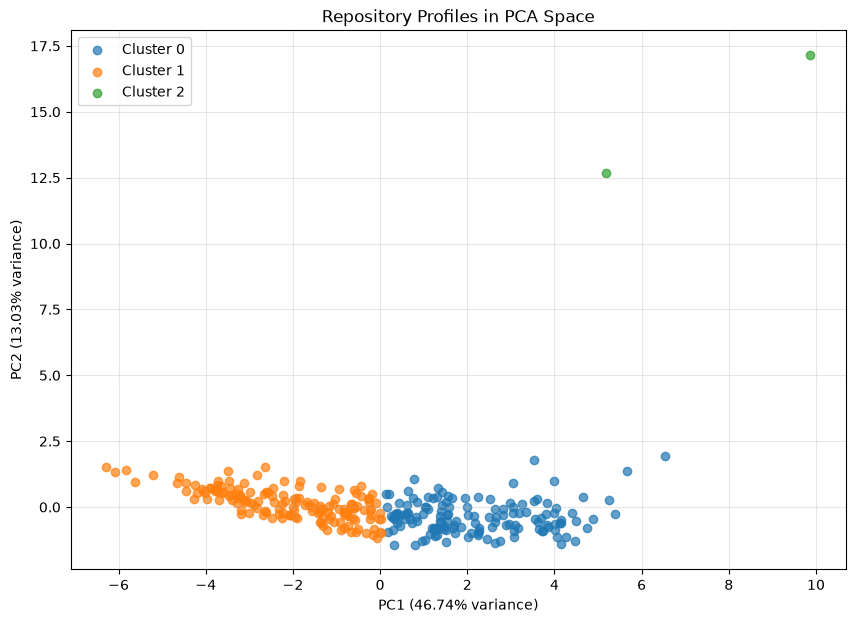

In [33]:
plt.figure(figsize=(10, 7))

for cluster in sorted(
    pca_scores["cluster"].unique()
):

    subset = pca_scores[
        pca_scores["cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.7,
        label=f"Cluster {cluster}"
    )

plt.xlabel(
    "PC1 (46.74% variance)"
)

plt.ylabel(
    "PC2 (13.03% variance)"
)

plt.title(
    "Repository Profiles in PCA Space"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [34]:
cluster_comparison = (
    cluster_df
    .groupby("cluster")[
        [
            "log1p_stars",
            "log1p_forks",
            "log1p_commits_365d",
            "log1p_contributors_count",
            "active_months",
            "days_since_push",
            "days_since_update",
            "repository_age_years"
        ]
    ]
    .median()
)

cluster_comparison

,log1p_stars,log1p_forks,log1p_commits_365d,log1p_contributors_count,active_months,days_since_push,days_since_update,repository_age_years
cluster,,,,,,,,
0,10.684096,8.357494,5.758902,5.347108,12.0,3.0,0.0,8.104038
1,7.820038,5.802118,0.000000,2.772589,0.0,420.0,2.0,9.976728
2,12.650194,11.197314,11.441881,2.967447,12.0,0.0,0.0,7.926078


In [35]:
language_cluster = pd.crosstab(
    cluster_df["cluster"],
    cluster_df["language_normalized"]
)

language_cluster

language_normalized,assembly,blade,c,c#,c++,clojure,css,go,html,java,...,ruby,rust,shell,solidity,swift,typescript,unknown,vim script,vue,zig
cluster,,,,,,,,,,,,,,,,,,,,,
0,0,1,1,3,8,1,1,11,4,1,...,0,8,2,0,3,20,9,0,1,1
1,1,0,6,5,12,2,0,8,1,13,...,3,3,5,1,2,13,15,2,2,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [36]:
language_cluster_percentage = (
    pd.crosstab(
        cluster_df["cluster"],
        cluster_df["language_normalized"],
        normalize="index"
    ) * 100
)

language_cluster_percentage.round(2)

language_normalized,assembly,blade,c,c#,c++,clojure,css,go,html,java,...,ruby,rust,shell,solidity,swift,typescript,unknown,vim script,vue,zig
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.00,0.71,0.71,2.13,5.67,0.71,0.71,7.80,2.84,0.71,...,0.00,5.67,1.42,0.00,2.13,14.18,6.38,0.00,0.71,0.71
1,0.65,0.00,3.87,3.23,7.74,1.29,0.00,5.16,0.65,8.39,...,1.94,1.94,3.23,0.65,1.29,8.39,9.68,1.29,1.29,0.00
2,0.00,0.00,50.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,50.00,0.00,0.00,0.00,0.00


In [37]:
# Inspect the repositories assigned to each cluster

cluster_members = (
    cluster_df[
        [
            "repo_id",
            "full_name",
            "language_normalized",
            "stars",
            "forks",
            "commits_365d",
            "contributors_count",
            "active_months",
            "days_since_push",
            "days_since_update",
            "repository_age_years",
            "cluster"
        ]
    ]
    .sort_values(
        ["cluster", "commits_365d"],
        ascending=[True, False]
    )
)

cluster_members

,repo_id,full_name,language_normalized,stars,forks,commits_365d,contributors_count,active_months,days_since_push,days_since_update,repository_age_years,cluster
101,41881900,microsoft/vscode,typescript,192634,42482,26590.0,315.0,13.0,0,0,11.039014,0
274,975734319,anomalyco/opencode,typescript,208133,27347,13024.0,456.0,13.0,0,0,1.382615,0
252,666299222,openinterpreter/openinterpreter,rust,68364,5882,9498.0,474.0,13.0,3,0,3.181383,0
54,15634981,godotengine/godot,c++,117364,26776,9356.0,459.0,13.0,0,0,12.703628,0
192,193215554,n8n-io/n8n,typescript,204985,60738,9055.0,428.0,13.0,0,0,7.241615,0
...,...,...,...,...,...,...,...,...,...,...,...,...
251,662028682,graphdeco-inria/gaussian-splatting,python,23897,3430,0.0,12.0,0.0,336,1,3.208761,1
255,672673877,PeterGriffinJin/Awesome-Language-Model-on-Graphs,unknown,999,68,0.0,12.0,0.0,565,17,3.134839,1
269,915759691,disler/always-on-ai-assistant,python,998,213,0.0,2.0,0.0,613,10,1.678303,1
284,1103012935,openclaw/openclaw,typescript,389979,81976,96177.0,377.0,11.0,0,0,0.815880,2


In [38]:
print("Cluster 2 repositories")
print("======================")

cluster_members[
    cluster_members["cluster"] == 2
]

Cluster 2 repositories


,repo_id,full_name,language_normalized,stars,forks,commits_365d,contributors_count,active_months,days_since_push,days_since_update,repository_age_years,cluster
284,1103012935,openclaw/openclaw,typescript,389979,81976,96177.0,377.0,11.0,0,0,0.815880,2
16,2325298,torvalds/linux,c,249330,64888,90201.0,0.0,13.0,0,0,15.036277,2


In [39]:
cluster_distribution = (
    cluster_df["cluster"]
    .value_counts()
    .sort_index()
)

cluster_percentage = (
    cluster_distribution /
    len(cluster_df) *
    100
)

cluster_distribution_table = pd.DataFrame({
    "repositories": cluster_distribution,
    "percentage": cluster_percentage.round(2)
})

cluster_distribution_table

,repositories,percentage
cluster,,
0,141,47.32
1,155,52.01
2,2,0.67


In [40]:
cluster_activity_summary = (
    cluster_df
    .groupby("cluster")[
        [
            "commits_365d",
            "contributors_count",
            "stars",
            "forks",
            "active_months"
        ]
    ]
    .agg(
        ["median", "mean", "max"]
    )
)

cluster_activity_summary

commits_365d                        contributors_count              \
              median          mean      max             median        mean   
cluster                                                                      
0              316.0   1366.411348  26590.0              209.0  231.695035   
1                0.0     14.561290    363.0               15.0   27.167742   
2            93189.0  93189.000000  96177.0              188.5  188.500000   

                   stars                           forks                      \
           max    median           mean     max   median         mean    max   
cluster                                                                        
0        474.0   43655.0   76799.524823  547866   4261.0  10877.41844  84841   
1        199.0    2489.0    9003.219355  213636    330.0   1193.83871  21621   
2        377.0  319654.5  319654.500000  389979  73432.0  73432.00000  81976   

        active_months                   
               median       mean   max  
cluster                                 
0                12.0  10.333333  13.0  
1                 0.0   1.670968  13.0  
2                12.0  12.000000  13.0

In [41]:
# Compare cluster sizes for k=2 and k=3

for k in [2, 3]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    sizes = pd.Series(labels).value_counts().sort_index()

    print()
    print(f"k = {k}")
    print("-" * 20)

    for cluster, size in sizes.items():
        print(
            f"Cluster {cluster}: "
            f"{size} repositories "
            f"({size / len(labels) * 100:.2f}%)"
        )

    print(
        "Silhouette:",
        f"{silhouette_score(X_scaled, labels):.4f}"
    )


k = 2
--------------------
Cluster 0: 155 repositories (52.01%)
Cluster 1: 143 repositories (47.99%)
Silhouette: 0.2924

k = 3
--------------------
Cluster 0: 141 repositories (47.32%)
Cluster 1: 155 repositories (52.01%)
Cluster 2: 2 repositories (0.67%)
Silhouette: 0.2984


In [42]:
# Main repository-profile clustering

main_k = 2

main_kmeans = KMeans(
    n_clusters=main_k,
    random_state=42,
    n_init=20
)

main_labels = main_kmeans.fit_predict(X_scaled)

cluster_df["main_cluster"] = main_labels

print("Main clustering model")
print("=====================")
print("Number of clusters:", main_k)
print()

print("Cluster sizes:")

main_sizes = (
    pd.Series(main_labels)
    .value_counts()
    .sort_index()
)

for cluster, size in main_sizes.items():
    print(
        f"Cluster {cluster}: "
        f"{size} repositories "
        f"({size / len(main_labels) * 100:.2f}%)"
    )

print()
print(
    "Silhouette score:",
    f"{silhouette_score(X_scaled, main_labels):.4f}"
)

Main clustering model
Number of clusters: 2

Cluster sizes:
Cluster 0: 155 repositories (52.01%)
Cluster 1: 143 repositories (47.99%)

Silhouette score: 0.2924


In [43]:
main_cluster_profile = (
    cluster_df
    .groupby("main_cluster")
    .agg(
        repositories=("repo_id", "count"),

        median_stars=("stars", "median"),
        median_forks=("forks", "median"),

        median_commits_365d=(
            "commits_365d",
            "median"
        ),

        median_contributors=(
            "contributors_count",
            "median"
        ),

        median_active_months=(
            "active_months",
            "median"
        ),

        median_days_since_push=(
            "days_since_push",
            "median"
        ),

        median_days_since_update=(
            "days_since_update",
            "median"
        ),

        median_repository_age=(
            "repository_age_years",
            "median"
        ),

        median_top_contributor_share=(
            "top_contributor_share",
            "median"
        )
    )
    .reset_index()
)

main_cluster_profile

,main_cluster,repositories,median_stars,median_forks,median_commits_365d,median_contributors,median_active_months,median_days_since_push,median_days_since_update,median_repository_age,median_top_contributor_share
0,0,155,2489.0,330.0,0.0,15.0,0.0,420.0,2.0,9.976728,0.765625
1,1,143,43920.0,4455.0,326.0,209.0,12.0,3.0,0.0,8.104038,0.415698


In [44]:
main_cluster_means = (
    cluster_df
    .groupby("main_cluster")
    .agg(
        repositories=("repo_id", "count"),

        mean_stars=("stars", "mean"),
        mean_forks=("forks", "mean"),

        mean_commits_365d=(
            "commits_365d",
            "mean"
        ),

        mean_contributors=(
            "contributors_count",
            "mean"
        ),

        mean_active_months=(
            "active_months",
            "mean"
        ),

        mean_days_since_push=(
            "days_since_push",
            "mean"
        ),

        mean_days_since_update=(
            "days_since_update",
            "mean"
        ),

        mean_repository_age=(
            "repository_age_years",
            "mean"
        ),

        mean_top_contributor_share=(
            "top_contributor_share",
            "mean"
        )
    )
    .reset_index()
)

main_cluster_means

,main_cluster,repositories,mean_stars,mean_forks,mean_commits_365d,mean_contributors,mean_active_months,mean_days_since_push,mean_days_since_update,mean_repository_age,mean_top_contributor_share
0,0,155,9003.219355,1193.838710,14.561290,27.167742,1.670968,730.309677,5.761290,9.287638,0.725370
1,1,143,80196.097902,11752.307692,2650.643357,231.090909,10.356643,23.125874,0.636364,7.837931,0.469548


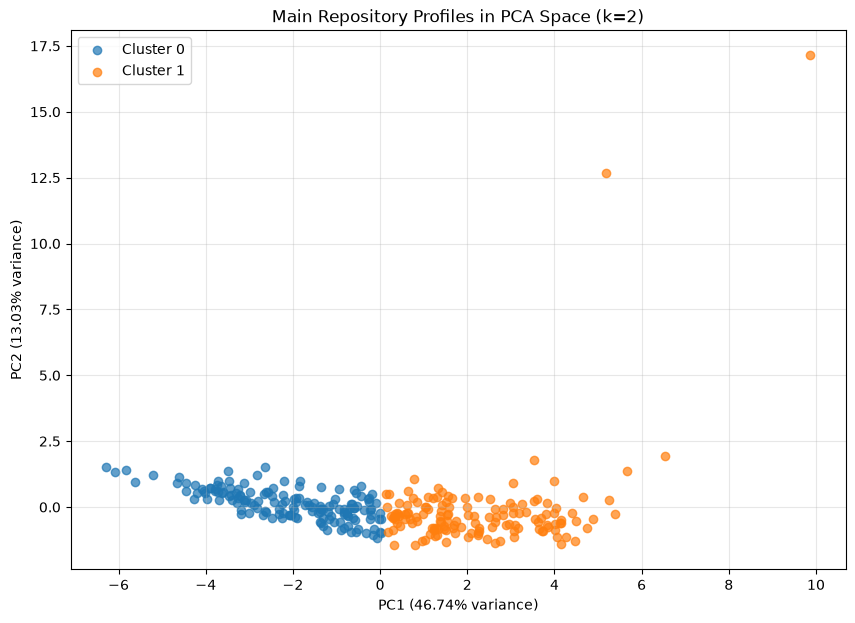

In [45]:
# PCA visualization of the main k=2 clustering

main_pca = pca_scores.copy()
main_pca["main_cluster"] = main_labels

plt.figure(figsize=(10, 7))

for cluster in sorted(
    main_pca["main_cluster"].unique()
):

    subset = main_pca[
        main_pca["main_cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.7,
        label=f"Cluster {cluster}"
    )

plt.xlabel(
    "PC1 (46.74% variance)"
)

plt.ylabel(
    "PC2 (13.03% variance)"
)

plt.title(
    "Main Repository Profiles in PCA Space (k=2)"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [46]:
main_cluster_comparison = (
    cluster_df
    .groupby("main_cluster")[
        [
            "log1p_stars",
            "log1p_forks",
            "log1p_commits_365d",
            "log1p_contributors_count",
            "active_months",
            "days_since_push",
            "days_since_update",
            "repository_age_years",
            "top_contributor_share"
        ]
    ]
    .median()
)

main_cluster_comparison

,log1p_stars,log1p_forks,log1p_commits_365d,log1p_contributors_count,active_months,days_since_push,days_since_update,repository_age_years,top_contributor_share
main_cluster,,,,,,,,,
0,7.820038,5.802118,0.00000,2.772589,0.0,420.0,2.0,9.976728,0.765625
1,10.690148,8.402007,5.78996,5.347108,12.0,3.0,0.0,8.104038,0.415698


In [47]:
# Save clustering evaluation

cluster_evaluation.to_csv(
    "../reports/kmeans_evaluation.csv",
    index=False
)

# Save main cluster profiles

main_cluster_profile.to_csv(
    "../reports/kmeans_cluster_profiles.csv",
    index=False
)

# Save repository-level cluster assignments

cluster_output = cluster_df[
    [
        "repo_id",
        "full_name",
        "language_normalized",
        "main_cluster"
    ]
].copy()

cluster_output.to_csv(
    "../reports/kmeans_repository_clusters.csv",
    index=False
)

print("K-Means results saved successfully.")

K-Means results saved successfully.
